# section 2 — PyTorch Lightning, through MassSpecGym's own architecture

See `README.md` in this folder for the full plan and reasoning. Quick recap: this section is not a
generic Lightning tutorial — it's specifically about the `LightningModule` contract MassSpecGym's own
codebase is built on (`MassSpecGymModel` -> `RetrievalMassSpecGymModel` -> a concrete model), practiced
against their real data pipeline on their own small debug set (5 real spectra).

Before writing any code, read `massspecgym/models/base.py` and `massspecgym/models/retrieval/base.py`
in your installed environment (`.venv/Lib/site-packages/massspecgym/models/...`). This notebook assumes
you've done that — it won't re-explain what's in those files.


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning.loggers import WandbLogger

from massspecgym.data import RetrievalDataset, MassSpecDataModule
from massspecgym.data.transforms import SpecBinner, MolFingerprinter
from massspecgym.models.retrieval import RetrievalMassSpecGymModel, RandomRetrieval, FingerprintFFNRetrieval

pl.seed_everything(0)

DEBUG_MGF = Path("../data/massspecgym_debug/example_5_spectra.mgf")
DEBUG_CANDIDATES = Path("../data/massspecgym_debug/example_5_spectra_candidates.json")
DEBUG_SPLIT = Path("../data/massspecgym_debug/example_5_spectra_split.tsv")


Seed set to 0


## Phase 0 — orientation

Build the real MassSpecGym data pipeline for the retrieval task: `RetrievalDataset` (spectra + candidate
sets) wrapped by `MassSpecDataModule` (train/val/test splits + dataloaders), with `SpecBinner` as the
`spec_transform` (bins each spectrum into a fixed-length intensity vector — the same representation
`FingerprintFFNRetrieval` expects) and `MolFingerprinter` as the `mol_transform` (turns each molecule into
a binary fingerprint of `fp_size` bits — this becomes both the training target and the representation
candidates get scored in).

Look up the constructor signatures for `RetrievalDataset` and `MassSpecDataModule` (both importable
directly; check their docstrings/type hints) rather than guessing the argument names.


In [4]:
dataset = RetrievalDataset(
    spec_transform = SpecBinner(),
    mol_transform = MolFingerprinter(),
    pth = DEBUG_MGF,
    candidates_pth = str(DEBUG_CANDIDATES)
    )

data_module = MassSpecDataModule(
    dataset = dataset,
    batch_size = 2,
    split_pth = DEBUG_SPLIT
)

Inspect the data (use plots)


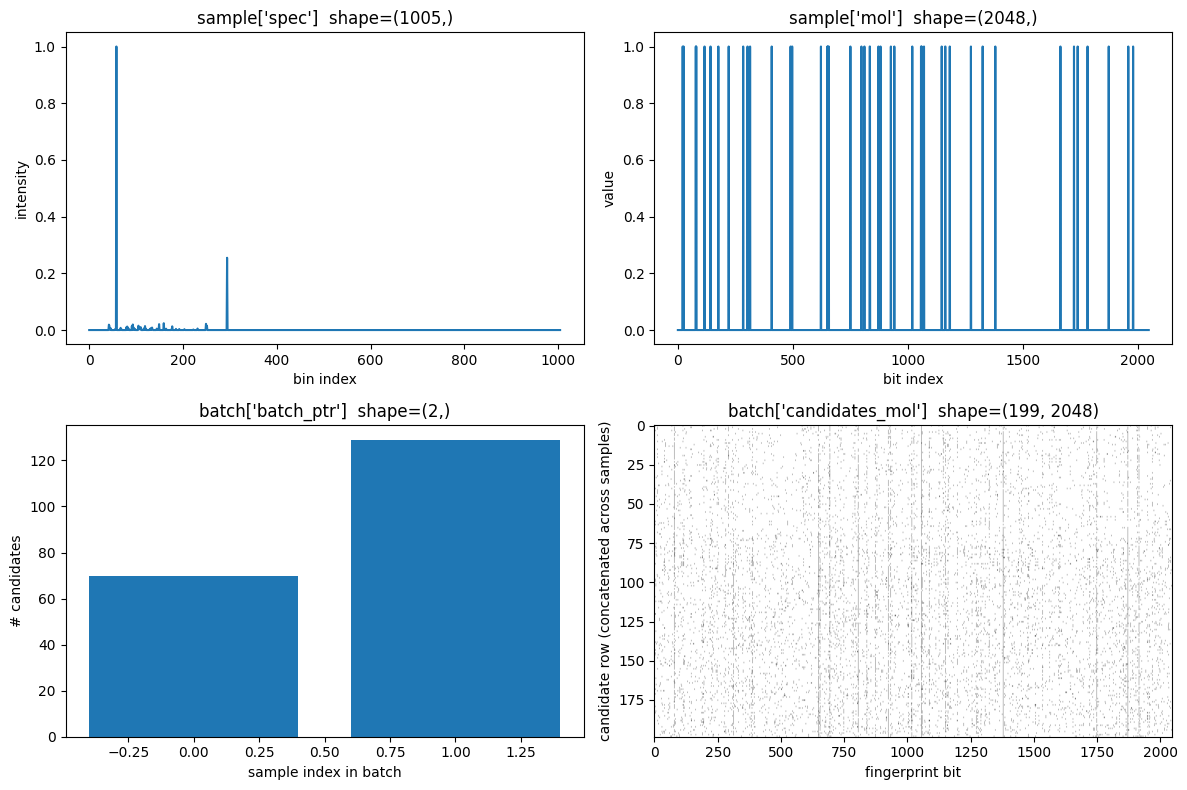

In [5]:
sample = dataset[0]
data_module.prepare_data()
data_module.setup()
batch = next(iter(data_module.train_dataloader()))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sample["spec"].numpy())
axes[0, 0].set_title(f"sample['spec']  shape={tuple(sample['spec'].shape)}")
axes[0, 0].set_xlabel("bin index")
axes[0, 0].set_ylabel("intensity")

axes[0, 1].plot(sample["mol"].numpy())
axes[0, 1].set_title(f"sample['mol']  shape={tuple(sample['mol'].shape)}")
axes[0, 1].set_xlabel("bit index")
axes[0, 1].set_ylabel("value")

counts = batch["batch_ptr"].numpy()
axes[1, 0].bar(range(len(counts)), counts)
axes[1, 0].set_title(f"batch['batch_ptr']  shape={tuple(batch['batch_ptr'].shape)}")
axes[1, 0].set_xlabel("sample index in batch")
axes[1, 0].set_ylabel("# candidates")

# NOTE: MassSpecGym v1.5 renamed this batch key from "candidates" to "candidates_mol"
# (RetrievalDataset.__getitem__ now namespaces candidate tensors by mol_transform key).
axes[1, 1].imshow(batch["candidates_mol"].numpy(), aspect="auto", cmap="Greys")
axes[1, 1].set_title(f"batch['candidates_mol']  shape={tuple(batch['candidates_mol'].shape)}")
axes[1, 1].set_xlabel("fingerprint bit")
axes[1, 1].set_ylabel("candidate row (concatenated across samples)")

plt.tight_layout()
plt.show()

## Phase 1 — implement a retrieval model against their scaffolding

`RetrievalMassSpecGymModel` (which you read in `massspecgym/models/retrieval/base.py`) already implements
`on_batch_end` — it computes hit_rate@k, MCES@1, and calls `self.log(...)` for all of it. You do not need
to log anything yourself. What it needs from you is one method: `step(self, batch, stage)`, returning
`{"loss": ..., "scores": ...}`.

Design: a small feedforward network (`in_channels` = number of bins from `SpecBinner`, `out_channels` =
number of bits in fingerprint) that maps a binned spectrum to a predicted fingerprint (values in `[0, 1]` — what activation
gives you that?). Compare the predicted fingerprint against `batch["mol"]` for the loss (cosine similarity
is a reasonable choice for comparing two fingerprint-like vectors — `torch.nn.functional.cosine_similarity`
does NOT give you a loss directly, since higher cosine similarity is better; think about how to turn it
into something to minimize).

The harder piece: turning your one predicted fingerprint per spectrum into `scores` against every
candidate. Each sample has a different number of candidates, concatenated together with `batch_ptr`
telling you how many candidates belong to each sample. Look up `torch.repeat_interleave` — what would
repeating each predicted fingerprint according to `batch_ptr` before comparing against `batch["candidates"]`
give you?

Do not look at `massspecgym/models/retrieval/fingerprint_ffn.py` until you've implemented this yourself —
compare afterward, not before.


In [6]:
class MyFingerprintRetrieval(RetrievalMassSpecGymModel):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int, **kwargs):
        super().__init__(**kwargs)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pred_fp = self.fc(x)
        return pred_fp

    def step(self, batch: dict, stage=None) -> dict:
        pred_fp = self.forward(batch['spec'])

        fp_sim = F.cosine_similarity(pred_fp, batch["mol"], dim=1)
        loss = (1 - fp_sim).mean()

        # Evaluation performance on fingerprint prediction (optional)
        self.evaluate_fingerprint_step(batch['mol'], pred_fp, stage=stage)

        # NOTE: MassSpecGym v1.5 renamed this batch key from "candidates" to "candidates_mol".
        pred_rep = torch.repeat_interleave(pred_fp, batch['batch_ptr'], dim=0)
        scores = F.cosine_similarity(pred_rep, batch['candidates_mol'], dim=1)

        return {"loss": loss, "scores": scores}

## Phase 2 — train it with their `Trainer` + `WandbLogger`

`WandbLogger` is a different idiom from calling `wandb.init()`/`wandb.log()` yourself: you hand it to the
`Trainer`, and every `self.log(...)` call anywhere in the model (including the ones already happening
inside `RetrievalMassSpecGymModel.on_batch_end`, which you didn't have to write) gets forwarded to it
automatically. Requires having run `wandb login` at least once.


In [7]:
model = MyFingerprintRetrieval(in_channels=1005, out_channels=2048, hidden_channels=512)
wandb_logger = WandbLogger(project="massspecgym-section02")

trainer = pl.Trainer(logger=wandb_logger, accelerator="cpu", max_epochs=5)
trainer.fit(model, data_module)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\YarivBNB03\_netrc.
wandb: Currently logged in as: ezra95ezra (ezra95ezra-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



  | Name | Type       | Params
------------------------------------
0 | fc   | Sequential | 1.8 M 
------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.313     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\YarivBNB03\code\metabolomics-ml-curriculum\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\YarivBNB03\code\metabolomics-ml-curriculum\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\YarivBNB03\code\metabolomics-ml-curriculum\.venv\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:298: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
